# Notebook Purpose

This Jupyter notebook retrieves the financial data of different assets in the same folder, then calculates the correlation between these assets, ranging from -1 for negatively correlated assets to 1 for positively correlated ones. Finally, it lists the 5 most positively correlated assets.

In [8]:
%pip install pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [9]:
DATA_DIR = "../../data/correlation_test"

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# Scan all CSV files in the folder
csv_files = glob.glob(f"{DATA_DIR}/*.csv")
print(f"CSVs trouvés ({len(csv_files)}):")
for f in csv_files:
    print(f"  - {Path(f).name}")

# Dictionary for storing data
prices = {}
for file in csv_files:
    ticker = Path(file).stem.split('_')[0]
    df = pd.read_csv(file, parse_dates=['Date']).set_index('Date')
    prices[ticker] = df['Adj Close']

# Combined DataFrame (common dates)
df_combined = pd.DataFrame(prices).dropna()
print(f"\nPériode commune ({len(df_combined.columns)} stocks):")
print(f"  {df_combined.index.min()} → {df_combined.index.max()}")
print(f"  {len(df_combined)} jours")

CSVs trouvés (5):
  - QQQ_1d_2009-04-01_2026-03-01.csv
  - TLT_1d_2009-04-01_2026-03-01.csv
  - SPY_1d_2009-04-01_2026-03-01.csv
  - GLD_1d_2009-04-01_2026-03-01.csv
  - XLE_1d_2009-04-01_2026-03-01.csv

Période commune (5 stocks):
  2009-04-01 00:00:00 → 2026-02-27 00:00:00
  4254 jours


In [11]:
returns = df_combined.pct_change().dropna()
corr_matrix = returns.corr()

print("Correlations (daily returns):")
print(corr_matrix.round(4))
print(f"\nMax correlation: {corr_matrix.values.max():.4f}")
print(f"Min correlation: {corr_matrix.values.min():.4f}")

Correlations (daily returns):
        QQQ     TLT     SPY     GLD     XLE
QQQ  1.0000 -0.2359  0.9292  0.0602  0.5182
TLT -0.2359  1.0000 -0.2988  0.1979 -0.3081
SPY  0.9292 -0.2988  1.0000  0.0628  0.6879
GLD  0.0602  0.1979  0.0628  1.0000  0.1092
XLE  0.5182 -0.3081  0.6879  0.1092  1.0000

Max correlation: 1.0000
Min correlation: -0.3081


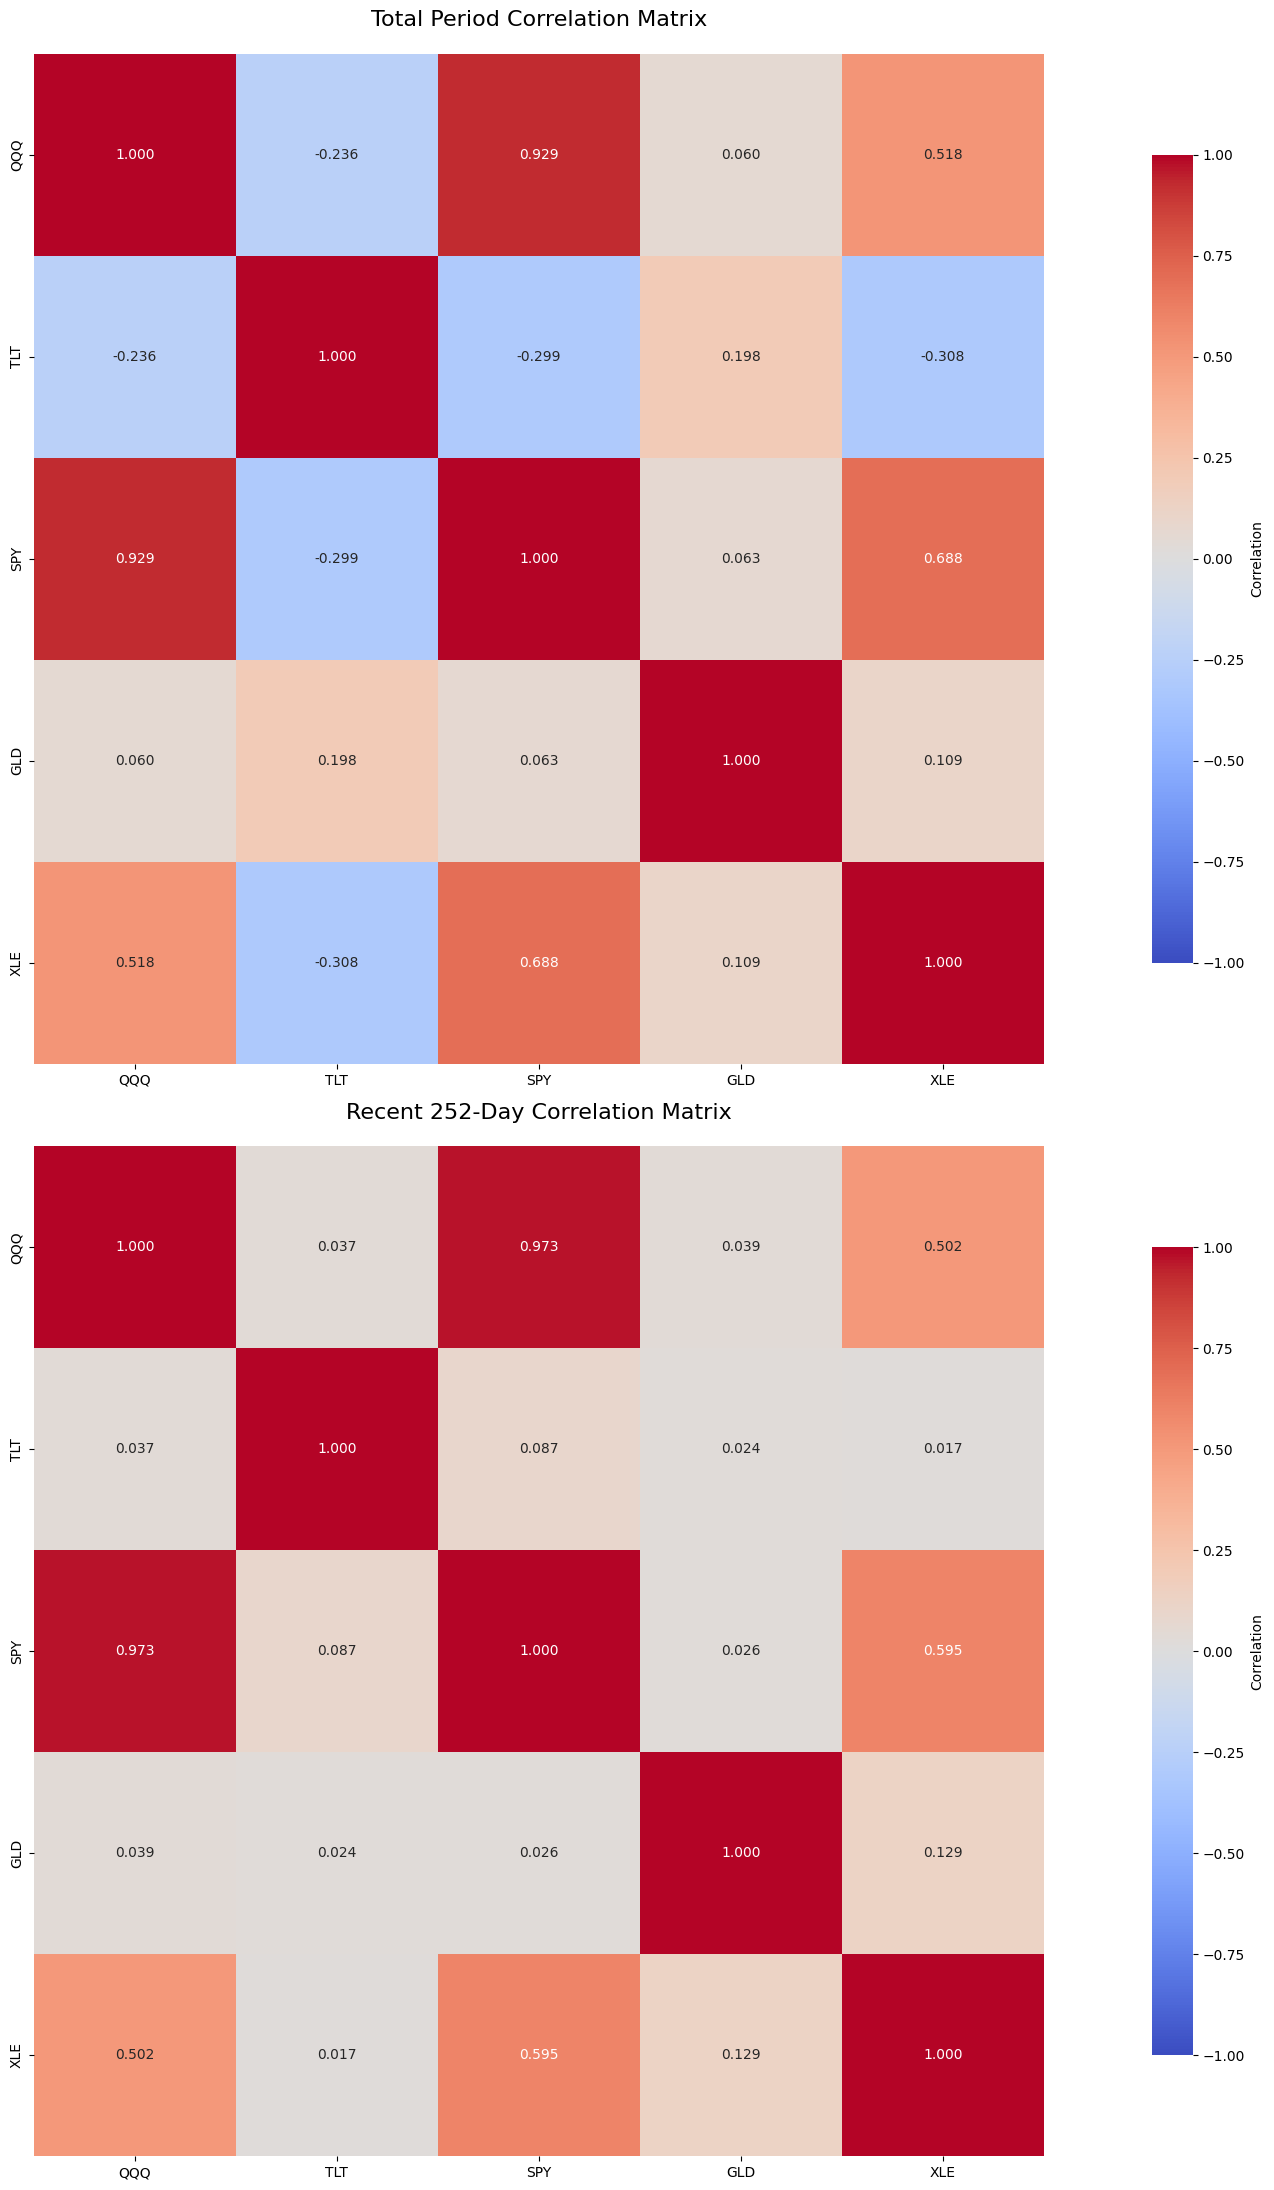

In [12]:
import numpy as np
import pandas as pd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 22))

# 1. Total Correlation Matrix (BLUE → RED, -1 to +1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax1)
ax1.set_title('Total Period Correlation Matrix', fontsize=16, pad=20)

# 2. 252-day Correlation Matrix (-1 to +1)
returns = df_combined.pct_change().dropna()
rolling_period = 252
recent_returns = returns.tail(rolling_period)
rolling_corr_matrix = recent_returns.corr()

sns.heatmap(rolling_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax2)
ax2.set_title('Recent 252-Day Correlation Matrix', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

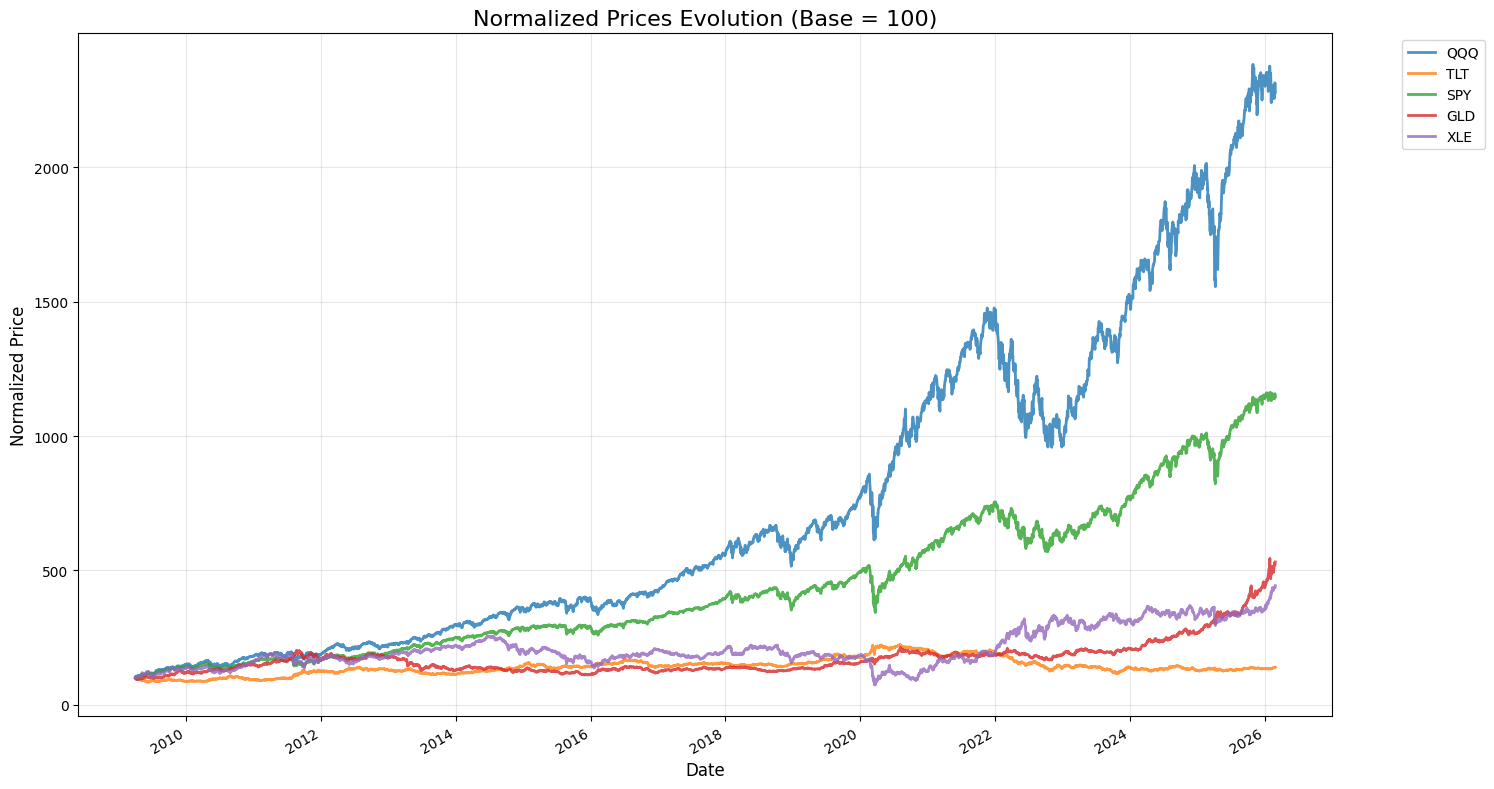

In [13]:
# Cellule VISU — Price Evolution (Normalized)
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Normalize prices to 100 at start (common comparison)
normalized_prices = (df_combined / df_combined.iloc[0]) * 100
normalized_prices.plot(ax=ax, linewidth=2, alpha=0.8)

ax.set_title('Normalized Prices Evolution (Base = 100)', fontsize=16)
ax.set_ylabel('Normalized Price', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Cellule TOP CORR — Top 5 Positive Correlations (SIMPLE)
import pandas as pd
import numpy as np

# Extract all unique pairs from upper triangle
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        asset1 = corr_matrix.columns[i]
        asset2 = corr_matrix.columns[j]
        corr = corr_matrix.loc[asset1, asset2]
        corr_pairs.append([asset1, asset2, corr])

# Convert to DataFrame and sort
corr_df = pd.DataFrame(corr_pairs, columns=['Asset1', 'Asset2', 'Correlation'])
top_corr = corr_df.nlargest(5, 'Correlation')

print("TOP 5 POSITIVE CORRELATIONS")
print("="*50)
if len(top_corr) > 0:
    for _, row in top_corr.iterrows():
        print(f"{row['Asset1']:>10} ↔ {row['Asset2']:>10} : {row['Correlation']:.4f}")
else:
    print("No positive correlations found")

TOP 5 POSITIVE CORRELATIONS
       QQQ ↔        SPY : 0.9292
       SPY ↔        XLE : 0.6879
       QQQ ↔        XLE : 0.5182
       TLT ↔        GLD : 0.1979
       GLD ↔        XLE : 0.1092
